# Measurement of the signal strength

$$\mathcal{L} (\mu | x) = \prod_{i}^{n} p (x_i | \mu) $$

In [1]:
import numpy as np
import matplotlib, matplotlib.pyplot as plt

import torch

from physics.simulation import mcfm
from physics.analysis import zz4l, zz2l2v
from physics.hstar import sigstr
from nsbi import carl

In [2]:
# Open the datasets

# predictions
events_4l = mcfm.from_csv(cross_section = None, file_path = '/ptmp/mpp/taepa/higgs-offshell-interpretation/data/zz4l/ggZZ_sbi/analyzed.csv', n_rows =1e5)
# events_gg_2l2v = 

lhc_lumi = 300.

In [23]:
mu_asimov = 0.5
mu_scan = np.linspace(0.0, 10.0, 101)

w_4l_asimov, p_4l_scan = sigstr.scale(events_4l, signal_strength = mu_asimov)
w_4l_scan, p_4l_scan = sigstr.scale(events_4l, signal_strength = mu_scan)

/ptmp/mpp/taepa/higgs-offshell-interpretation/physics/hstar/sigstr.py:26: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  p_scaled = torch.tensor(w_scaled / torch.sum(w_scaled, dim=0))


# Evaluating the likelihood: rate term

sigma_4l_scan = torch.sum(w_scan, dim=0)
nu_4l_scan = sigma_4l_scan * lhc_lumi

sigma_4l_asimov = torch.sum(w_asimov, dim=0)
nu_4l_asimov = sigma_4l_asimov * lhc_lumi

In [24]:
lhc_lumi = 300.0  # ifb

nu_4l_sm = torch.tensor((events_4l.weights * lhc_lumi).sum())

nu_4l_asimov = torch.sum(w_4l_asimov) * lhc_lumi
nu_4l_scan = torch.sum(w_4l_scan,dim=0) * lhc_lumi

In [25]:
t_4l_rate = -2 * nu_4l_asimov * (np.log(nu_4l_scan) - np.log(nu_4l_sm)) + 2 * (nu_4l_scan - nu_4l_sm) 

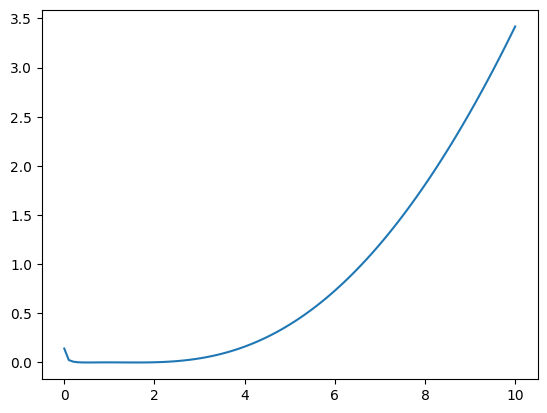

In [26]:
plt.plot(mu_scan, t_4l_rate)
plt.show()

# Evaluating the likelihood (ratio): shape term

Here comes the NSBI!

In [ ]:
run_dir = 'run/mu/h4l'

(events_n_train, events_n_test), (events_d_train, events_d_test), scaler_sbi_over_bkg, model_bi_over_bkg = carl.utils.load_results(run_dir, 'sbi_over_bkg')
features = ['l1_pt', 'l1_eta', 'l1_phi', 'l1_energy', 'l2_pt', 'l2_eta', 'l2_phi', 'l2_energy', 'l3_pt', 'l3_eta', 'l3_phi', 'l3_energy', 'l4_pt', 'l4_eta', 'l4_phi', 'l4_energy']

(events_n_train, events_n_test), (events_d_train, events_d_test), scaler_sig_over_bkg, model_sig_over_bkg = carl.utils.load_results(run_dir, 'sig_over_bkg')
features = ['l1_pt', 'l1_eta', 'l1_phi', 'l1_energy', 'l2_pt', 'l2_eta', 'l2_phi', 'l2_energy', 'l3_pt', 'l3_eta', 'l3_phi', 'l3_energy', 'l4_pt', 'l4_eta', 'l4_phi', 'l4_energy']